# Etapa Técnica - Analista de Dados Jr.
**Autora:** Bruna Oliveira Pedroso de Jesus

**Data:** 04/05/2026

## Importação de bibliotecas

In [1]:
!pip install squarify -q

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import squarify

In [3]:
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12,6)

In [15]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Camada bronze
Para garantir a estabilidade e a reprodutibilidade da execução, utilizei o Google Drive como staging area. Isso contorna os frequentes timeouts do servidor de dados abertos da ANEEL e garante que a esteira de processamento não falhe por instabilidade de rede externa.

In [16]:
caminho_arquivo = '/content/drive/MyDrive/ucmt_pj.csv'

In [17]:
print("Lendo arquivo do Google Drive...")
df_bronze = pd.read_csv(caminho_arquivo, sep=';', encoding='latin1', decimal=',', low_memory=False)
print("Sucesso!")

Lendo arquivo do Google Drive...
Sucesso!


In [18]:
print(f"Dados carregados! Linhas: {df_bronze.shape[0]}, Colunas: {df_bronze.shape[1]}")

Dados carregados! Linhas: 312074, Colunas: 80


## Camada Silver
Nesta etapa, o foco foi a governança e a qualidade do dado. Os filtros aplicados garantem que apenas clientes com situação ativa (SIT_ATIV == 'AT') sejam considerados.

Também foi realizado o tratamento da tipagem das colunas de indicadores, convertendo o formato de decimais do padrão brasileiro (vírgulas) para float, garantindo que as agregações matemáticas funcionem corretamente e que eventuais sujeiras na base se tornem nulos tratados (fillna).

In [44]:
print("Processando camada Silver (Limpeza)...")
df_silver = df_bronze.copy()


Processando camada Silver (Limpeza)...


In [21]:
if 'SIT_ATIV' in df_silver.columns:
    df_silver = df_silver[df_silver['SIT_ATIV'] == 'AT']

In [22]:
df_silver.columns = [col.strip().upper() for col in df_silver.columns]

In [23]:
cols_energia = [f'ENE_{str(i).zfill(2)}' for i in range(1, 13)]
cols_interrupcao_dur = [f'DIC_{str(i).zfill(2)}' for i in range(1, 13)]
cols_interrupcao_freq = [f'FIC_{str(i).zfill(2)}' for i in range(1, 13)]

In [24]:
colunas_foco = ['MUN', 'CNAE', 'CLAS_SUB', 'CAR_INST'] + cols_energia + cols_interrupcao_dur + cols_interrupcao_freq
df_silver = df_silver[colunas_foco]

In [32]:
df_silver.fillna(0, inplace=True)

## Camada Gold
Com a base higienizada, consolidei as métricas mensais em visões anuais. O principal diferencial desta camada foi a modelagem da flag CLIENTE_EM_RISCO.


Regra assumida: Cruzamento do quartil superior (top 25%) de consumo total com o quartil superior de tempo de interrupção (DIC). O objetivo é sinalizar para a área Comercial quais são os clientes de alto valor (maior receita) que estão sofrendo com a pior qualidade de serviço técnico, facilitando ações de retenção e manutenção preventiva.

In [33]:
print("Processando camada Gold (Métricas de Negócio)...")
df_gold = df_silver.copy()

Processando camada Gold (Métricas de Negócio)...


In [34]:
df_gold['CONSUMO_TOTAL_ANO'] = df_gold[cols_energia].sum(axis=1)
df_gold['DURACAO_QUEDAS_ANO'] = df_gold[cols_interrupcao_dur].sum(axis=1)
df_gold['FREQUENCIA_QUEDAS_ANO'] = df_gold[cols_interrupcao_freq].sum(axis=1)

In [35]:
limite_consumo = df_gold['CONSUMO_TOTAL_ANO'].quantile(0.75)
limite_quedas = df_gold['DURACAO_QUEDAS_ANO'].quantile(0.75)

In [36]:
df_gold['CLIENTE_EM_RISCO'] = np.where(
    (df_gold['CONSUMO_TOTAL_ANO'] > limite_consumo) & (df_gold['DURACAO_QUEDAS_ANO'] > limite_quedas),
    'Sim', 'Não'
)

## Análise Exploratória e Visualização
As visualizações foram estruturadas para responder de forma ágil às necessidades do negócio:

Geografia da Receita: Mapeamento dos municípios com maior representatividade no consumo.

Matriz de Risco: Visão clara do volume de clientes críticos mapeados na camada Gold em relação à base total.

Sazonalidade: Curva de demanda para auxiliar a operação a prever meses de pico.

In [45]:
print("Gerando visualizações...")
top_municipios = df_gold.groupby('MUN')['CONSUMO_TOTAL_ANO'].sum().sort_values(ascending=False).head(10)

Gerando visualizações...


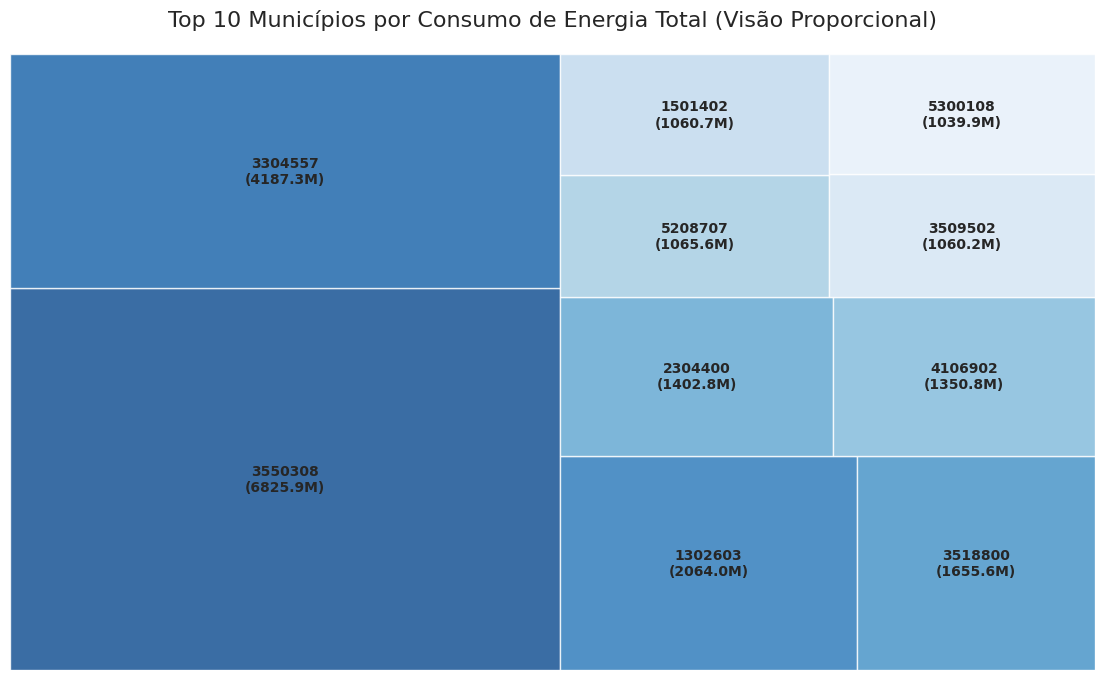

In [39]:
plt.figure(figsize=(14, 8))
cores = sns.color_palette("Blues_r", len(top_municipios))
squarify.plot(sizes=top_municipios.values,
              label=[f"{mun}\n({val/1e6:.1f}M)" for mun, val in zip(top_municipios.index, top_municipios.values)],
              color=cores, alpha=0.8, text_kwargs={'fontsize':10, 'weight':'bold'})
plt.title('Top 10 Municípios por Consumo de Energia Total', fontsize=16, pad=20)
plt.axis('off')
plt.show()

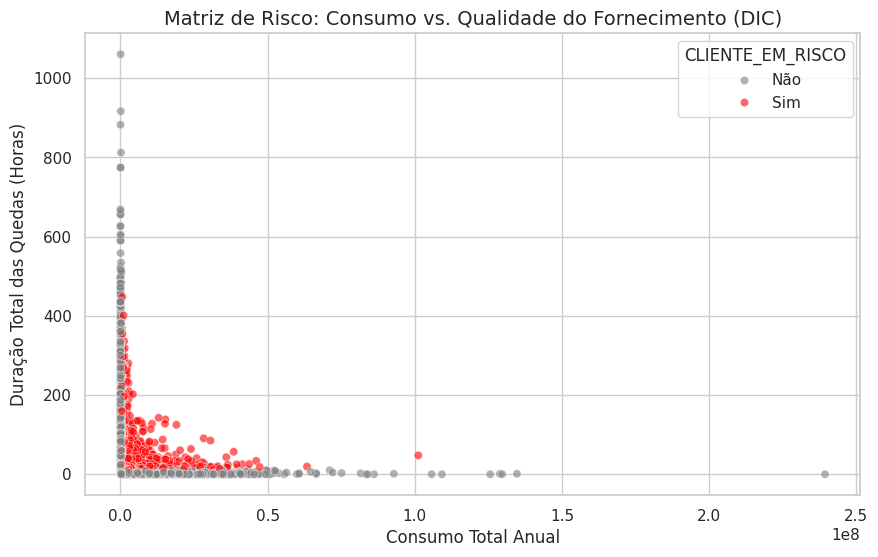

In [40]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_gold, x='CONSUMO_TOTAL_ANO', y='DURACAO_QUEDAS_ANO',
                hue='CLIENTE_EM_RISCO', palette={'Sim': 'red', 'Não': 'grey'}, alpha=0.6)
plt.title('Matriz de Risco: Consumo vs. Qualidade do Fornecimento (DIC)', fontsize=14)
plt.xlabel('Consumo Total Anual')
plt.ylabel('Duração Total das Quedas (Horas)')
plt.show()

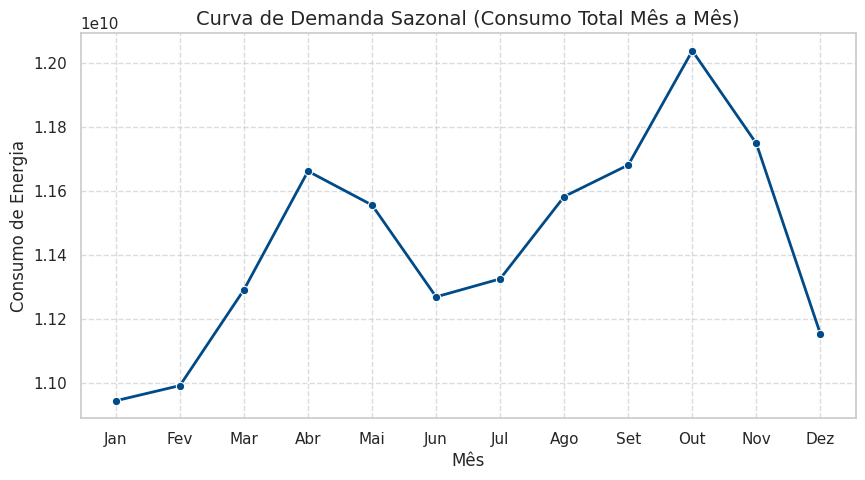

In [43]:
consumo_mensal = df_gold[cols_energia].sum()

consumo_mensal.index = ['Jan', 'Fev', 'Mar', 'Abr', 'Mai', 'Jun', 'Jul', 'Ago', 'Set', 'Out', 'Nov', 'Dez']

plt.figure(figsize=(10, 5))
sns.lineplot(x=consumo_mensal.index, y=consumo_mensal.values, marker='o', color='#004b87', linewidth=2)
plt.title('Curva de Demanda Sazonal (Consumo Total Mês a Mês)', fontsize=14)
plt.xlabel('Mês')
plt.ylabel('Consumo de Energia')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()